In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [7]:
def goster(baslik, resim, cmap_turu='gray'):
    plt.figure(figsize=(6, 6))
    plt.title(baslik)
    plt.imshow(resim, cmap=cmap_turu)
    plt.axis('off')
    plt.show()

In [8]:
orijinal_img = cv2.imread('SOB.png')
orijinal_rgb = cv2.cvtColor(orijinal_img, cv2.COLOR_BGR2RGB)
print("Görüntü OpenCV ile okundu ve BGR'den RGB renk uzayına dönüştürüldü.")

Görüntü OpenCV ile okundu ve BGR'den RGB renk uzayına dönüştürüldü.


In [9]:
H_matrisi = orijinal_img[:, :, 1] 
print("SCN-RDL'den gelen H (Çekirdek) matrisi simüle edildi (Yeşil kanal ayrıldı).")

SCN-RDL'den gelen H (Çekirdek) matrisi simüle edildi (Yeşil kanal ayrıldı).


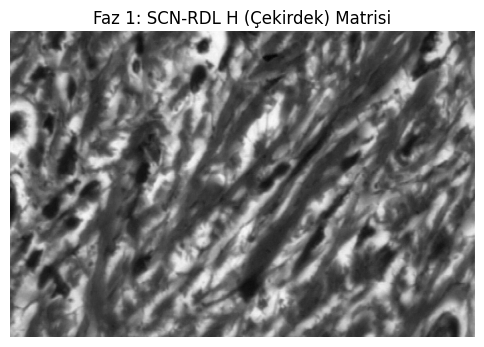

Elde edilen ham H matrisi, cv2.normalize ile 0-255 aralığına ölçeklendirilmiş (Min-Max) ve np.uint8 ile standart 8-bit gri seviye görüntü formatına dönüştürülmüştür.


In [10]:
H_norm = cv2.normalize(H_matrisi, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
H_uint8 = np.uint8(H_norm)

goster("Faz 1: SCN-RDL H (Çekirdek) Matrisi", H_uint8)
print("Elde edilen ham H matrisi, cv2.normalize ile 0-255 aralığına ölçeklendirilmiş (Min-Max) ve np.uint8 ile standart 8-bit gri seviye görüntü formatına dönüştürülmüştür.")

In [11]:
gri_img = H_uint8.copy()
print(" Normalize edilmiş matris 8-bit işaretsiz tamsayı (uint8) formatına çevrildi.")

 Normalize edilmiş matris 8-bit işaretsiz tamsayı (uint8) formatına çevrildi.


In [12]:
bilateral_img = cv2.bilateralFilter(gri_img, d=9, sigmaColor=75, sigmaSpace=75)
print("Hücre zarları korunarak iç gürültüleri temizlemek için Bilateral Filter uygulandı.")

Hücre zarları korunarak iç gürültüleri temizlemek için Bilateral Filter uygulandı.


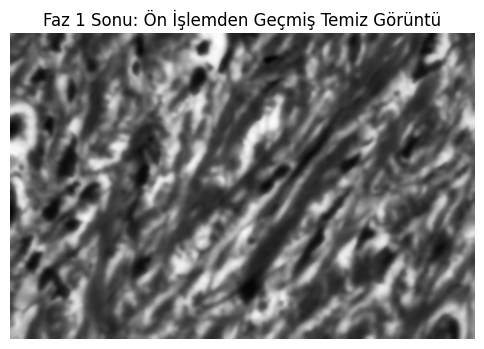

6: Görüntü eşiklemeye hazırlanması için hafif bir Gaussian Blur ile yumuşatıldı.


In [13]:
blur_img = cv2.GaussianBlur(bilateral_img, (3, 3), 0)

goster("Faz 1 Sonu: Ön İşlemden Geçmiş Temiz Görüntü", blur_img)
print("6: Görüntü eşiklemeye hazırlanması için hafif bir Gaussian Blur ile yumuşatıldı.")

In [14]:
_, otsu_mask = cv2.threshold(blur_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print("Görüntüdeki genel ışık farklılıklarını gidermek için Global Otsu Thresholding uygulandı.")

Görüntüdeki genel ışık farklılıklarını gidermek için Global Otsu Thresholding uygulandı.


In [15]:
adaptive_mask = cv2.adaptiveThreshold(blur_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                      cv2.THRESH_BINARY, 11, 2)
print("Bölgesel ışık dengesizliklerini çözmek için Adaptive Thresholding (Gaussian C) uygulandı.")

Bölgesel ışık dengesizliklerini çözmek için Adaptive Thresholding (Gaussian C) uygulandı.


In [16]:
birlestirilmis_maske = cv2.bitwise_and(otsu_mask, adaptive_mask)
print("9: Otsu ve Adaptive maskeleri cv2.bitwise_and ile birleştirilerek güçlü bir maske oluşturuldu.")

9: Otsu ve Adaptive maskeleri cv2.bitwise_and ile birleştirilerek güçlü bir maske oluşturuldu.


In [17]:
ters_maske = cv2.bitwise_not(birlestirilmis_maske)
print("Arka planı siyah, hücreleri beyaz yapmak için maskenin tersi (cv2.bitwise_not) alındı.")

Arka planı siyah, hücreleri beyaz yapmak için maskenin tersi (cv2.bitwise_not) alındı.


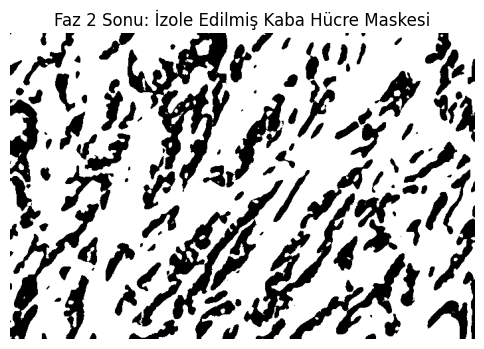

 Sadece hücrelerin piksellerini barındıran temizlenmiş (izole edilmiş) görüntü oluşturuldu.


In [19]:
izole_hucreler = cv2.bitwise_and(blur_img, blur_img, mask=ters_maske)

goster("Faz 2 Sonu: İzole Edilmiş Kaba Hücre Maskesi", ters_maske)
print(" Sadece hücrelerin piksellerini barındıran temizlenmiş (izole edilmiş) görüntü oluşturuldu.")

In [20]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
print("Morfolojik işlemler için 3x3 boyutunda dairesel (ellipse) bir çekirdek tanımlandı.")

Morfolojik işlemler için 3x3 boyutunda dairesel (ellipse) bir çekirdek tanımlandı.


In [21]:
opening = cv2.morphologyEx(ters_maske, cv2.MORPH_OPEN, kernel, iterations=1)
print("Dışarıdaki ufak beyaz gürültüleri silmek için Açma (Opening) işlemi uygulandı.")

Dışarıdaki ufak beyaz gürültüleri silmek için Açma (Opening) işlemi uygulandı.


In [22]:
closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel, iterations=2)
print("Hücrelerin içindeki siyah delikleri doldurmak için Kapama (Closing) işlemi uygulandı.")

Hücrelerin içindeki siyah delikleri doldurmak için Kapama (Closing) işlemi uygulandı.


In [23]:
erozyon = cv2.erode(closing, kernel, iterations=1)
print("Birbirine yapışık hücreleri ayırmak için Erozyon (Erosion) uygulandı.")

Birbirine yapışık hücreleri ayırmak için Erozyon (Erosion) uygulandı.


In [24]:
genisletme = cv2.dilate(erozyon, kernel, iterations=1)
print("Erozyonla formu bozulan hücreleri toparlamak için Genişletme (Dilation) uygulandı.")

Erozyonla formu bozulan hücreleri toparlamak için Genişletme (Dilation) uygulandı.


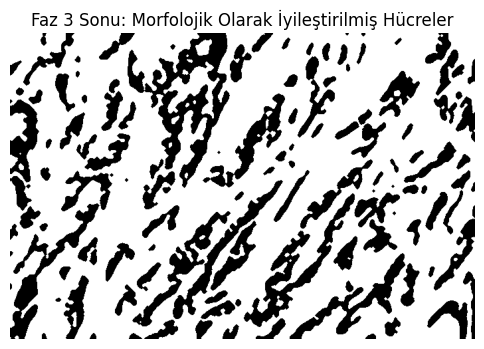

Morfolojik olarak iyileştirilmiş hücreleri barındıran maske sisteme kaydedildi.


In [25]:
morf_gradyan = cv2.morphologyEx(genisletme, cv2.MORPH_GRADIENT, kernel)
nihai_maske = genisletme.copy()

goster("Faz 3 Sonu: Morfolojik Olarak İyileştirilmiş Hücreler", nihai_maske)
print("Morfolojik olarak iyileştirilmiş hücreleri barındıran maske sisteme kaydedildi.")

In [26]:
sobelx = cv2.Sobel(nihai_maske, cv2.CV_64F, 1, 0, ksize=3)
sobelx = cv2.convertScaleAbs(sobelx)
print("Yataydaki kenarları bulmak için maske üzerine Sobel X filtresi uygulandı.")

Yataydaki kenarları bulmak için maske üzerine Sobel X filtresi uygulandı.


In [28]:
sobely = cv2.Sobel(nihai_maske, cv2.CV_64F, 0, 1, ksize=3)
sobely = cv2.convertScaleAbs(sobely)
print(" Dikeydeki kenarları bulmak için maske üzerine Sobel Y filtresi uygulandı.")

 Dikeydeki kenarları bulmak için maske üzerine Sobel Y filtresi uygulandı.


In [29]:
sobel_toplam = cv2.addWeighted(sobelx, 0.5, sobely, 0.5, 0)
print("Sobel X ve Y sonuçları cv2.addWeighted ile birleştirilerek toplam gradyan bulundu.")

Sobel X ve Y sonuçları cv2.addWeighted ile birleştirilerek toplam gradyan bulundu.


In [30]:
canny_kenar = cv2.Canny(nihai_maske, 100, 200)
print("Çok ince zar sınırlarını yakalamak için Canny Kenar Tespiti algoritması çalıştırıldı.")

Çok ince zar sınırlarını yakalamak için Canny Kenar Tespiti algoritması çalıştırıldı.


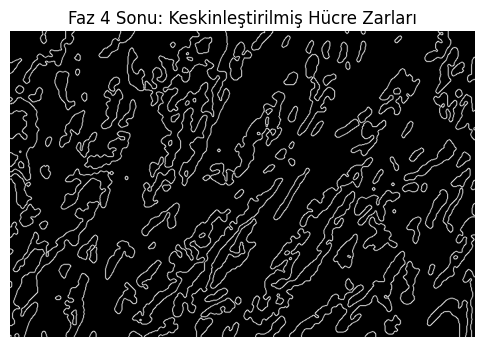

Canny sonuçları ile Morfolojik Gradyanı harmanlayıp keskin kenarlar elde edildi.


In [31]:
keskin_kenarlar = cv2.addWeighted(canny_kenar, 0.7, morf_gradyan, 0.3, 0)

goster("Faz 4 Sonu: Keskinleştirilmiş Hücre Zarları", keskin_kenarlar)
print("Canny sonuçları ile Morfolojik Gradyanı harmanlayıp keskin kenarlar elde edildi.")

In [32]:
konturlar, hiyerarsi = cv2.findContours(nihai_maske, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print("cv2.findContours fonksiyonu ile tespit edilen tüm hücre sınırlarının (konturların) koordinatları çıkarıldı.")

cv2.findContours fonksiyonu ile tespit edilen tüm hücre sınırlarının (konturların) koordinatları çıkarıldı.


In [33]:
gecerli_hucreler = []
final_gorsel = orijinal_rgb.copy()
print("Geçerli hücreleri saymak için boş bir liste oluşturuldu ve analiz döngüsü başlatıldı.")

Geçerli hücreleri saymak için boş bir liste oluşturuldu ve analiz döngüsü başlatıldı.


In [37]:
for cnt in konturlar:
    alan = cv2.contourArea(cnt)
    if alan > 30: # Bu eşik değeri veri setine göre değiştirilebilir
        gecerli_hucreler.append(cnt)

print(f"Tespit Edilen Kanserli/Şüpheli Hücre Çekirdeği Sayısı: {len(gecerli_hucreler)}")

Tespit Edilen Kanserli/Şüpheli Hücre Çekirdeği Sayısı: 18


In [38]:
cv2.drawContours(final_gorsel, gecerli_hucreler, -1, (0, 255, 0), 2)


array([[[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [235, 144, 224],
        ...,
        [176, 105, 185],
        [  0, 255,   0],
        [  0, 255,   0]],

       ...,

       [[225, 173, 212],
        [235, 176, 224],
        [242, 177, 231],
        ...,
        [218, 163, 220],
        [216, 169, 221],
        [219, 181, 228]],

       [[223, 171, 210],
        [234, 172, 221],
        [239, 174, 228],
        ...,
        [218, 160, 219],
        [214, 165, 220],
        [215, 176, 223]],

       [[221, 169, 208],
        [231, 169, 218],
        [242, 175, 229],
        ...,
        [217, 161, 222],
        [212, 163, 218],
        [219, 180, 227]]

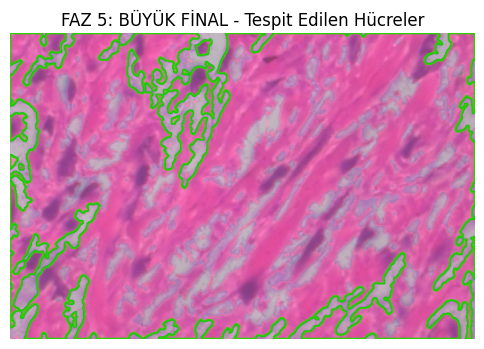

In [32]:
kirmizi_maske = np.zeros_like(orijinal_rgb)
kirmizi_maske[:,:,0] = nihai_maske 
sonuc_blend = cv2.addWeighted(final_gorsel, 0.8, kirmizi_maske, 0.2, 0)

goster("FAZ 5: BÜYÜK FİNAL - Tespit Edilen Hücreler", sonuc_blend, cmap_turu=None)